In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [30]:
bgg_games = pd.read_csv('data/source/bgg_games.csv')

Moda por columna:
row_id                 [3, 5, 12, 42, 47, 50, 54, 91, 93, 118, 172, 1...
type                                                         [boardgame]
name                                                       [Love Letter]
min_players                                                          [2]
max_players                                                          [4]
playingtime                                                         [30]
minimum_age                                                          [8]
release_year                                                      [2019]
average_rating                                                     [6.5]
num_of_ratings                                                      [32]
weight                                                             [1.0]
num_of_weights                                                       [3]
bayes_average                                                  [5.50022]
std_deviation                    

In [11]:
variables_graficas =['rank_boardgame', 'average_rating', 'release_year', 'playingtime', 'weight', 'min_players', 'max_players','bayes_average']
df = bgg_games[variables_graficas].copy()
df.head()

,rank_boardgame,average_rating,release_year,playingtime,weight,min_players,max_players,bayes_average
0,1.0,8.56433,2018,120,3.8607,2,4,8.39353
1,1.0,8.56433,2018,120,3.8607,2,4,8.39353
2,1.0,8.56433,2018,120,3.8607,2,4,8.39353
3,1.0,8.56433,2018,120,3.8607,2,4,8.39353
4,2.0,8.54058,2021,150,3.7963,1,4,8.35456


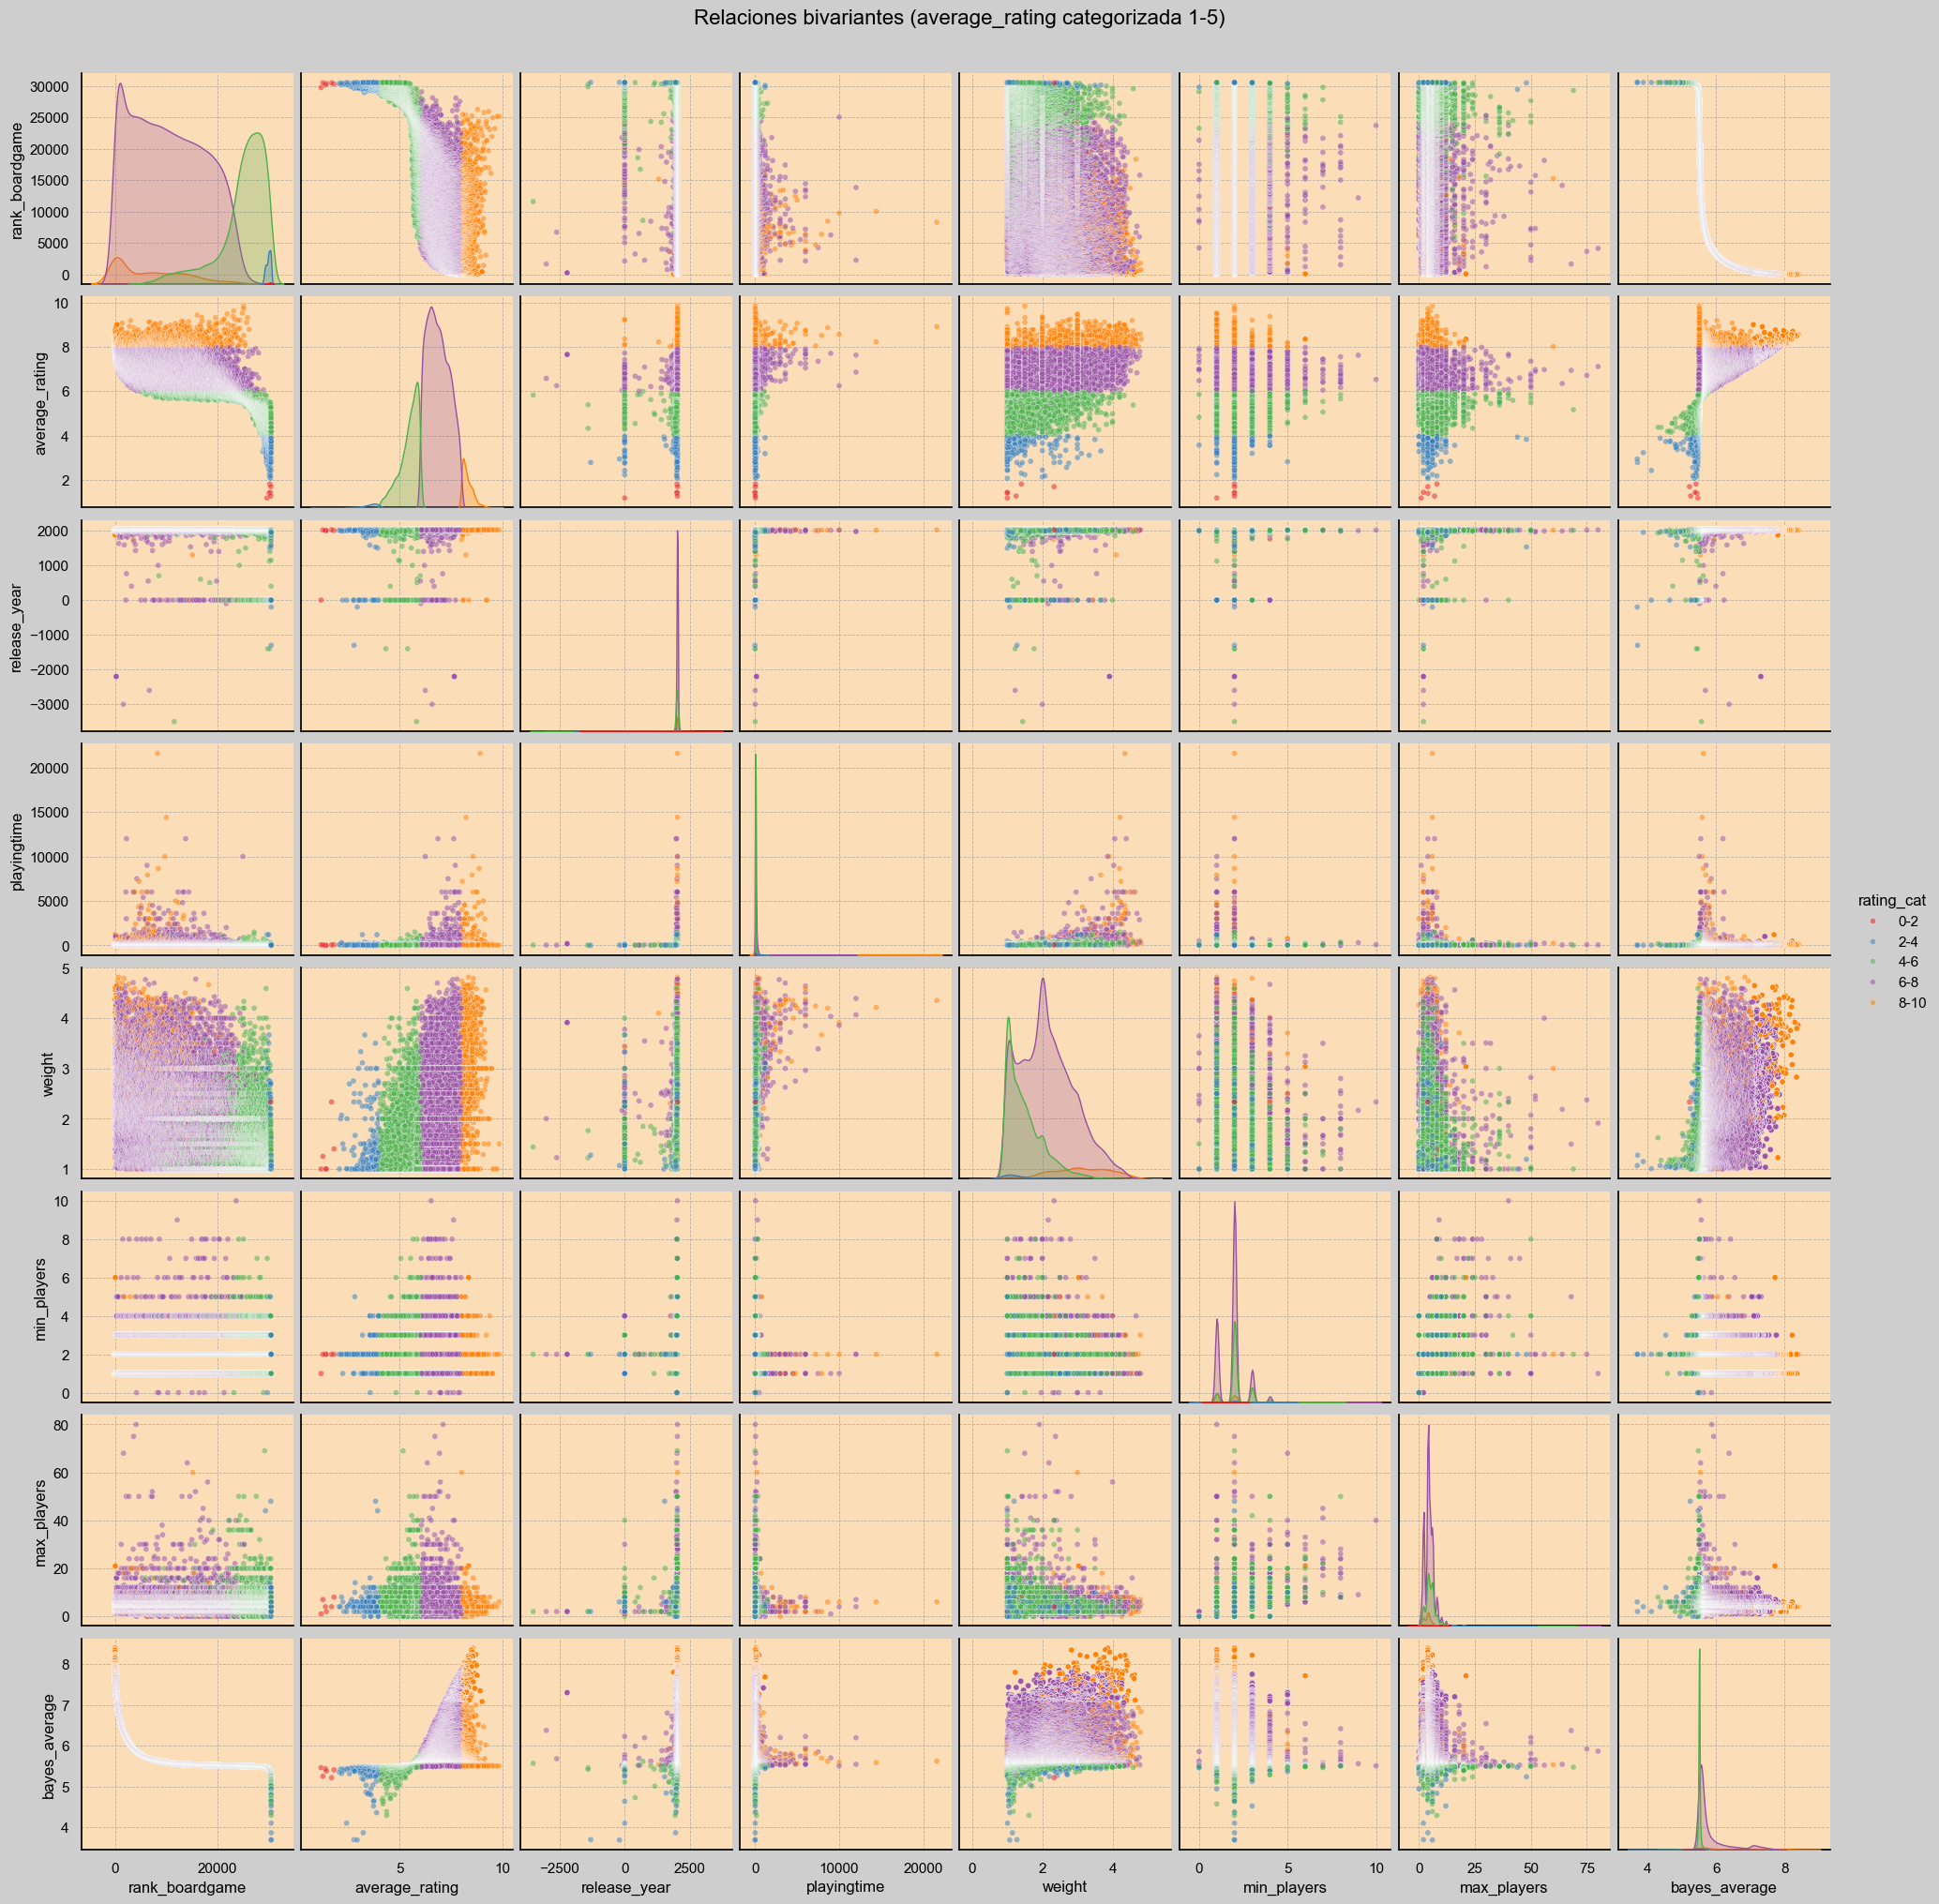

In [12]:
#-- IGNORE --
# Convertimos average_rating a categoría 1-5
df_plot = df.dropna().copy()

df_plot['rating_cat'] = pd.cut(
    df_plot['average_rating'],
    bins=[0, 2, 4, 6, 8, 10],
    labels=["0-2", "2-4", "4-6", "6-8", "8-10"],
    include_lowest=True
).astype('category')

vars_estudio = [c for c in df_plot.columns if c not in ['rating_cat']]
paleta = sns.color_palette("Set1", 5)

# Estilo general
fondo_global = "#CECECE"
fondo_grafico = "#FBDDB8"
sns.set_theme(style="whitegrid", rc={
    "figure.facecolor": fondo_global,
    "axes.facecolor": fondo_grafico,
    "axes.edgecolor": "black",
    "grid.color": "#B8B0A3",
    "grid.linestyle": "--",
    "grid.linewidth": 0.6,
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "text.color": "black",
})

g = sns.pairplot(
    df_plot,
    vars=vars_estudio,
    hue='rating_cat',
    hue_order=["0-2", "2-4", "4-6", "6-8", "8-10"],
    palette=paleta,
    diag_kind='kde',
    plot_kws={'alpha': 0.5, 's': 20}
)

g.figure.patch.set_facecolor(fondo_global)

for ax in g.axes.flatten():
    if ax is not None:
        ax.set_facecolor(fondo_grafico)
        ax.grid(True, which='major', color='#B8B0A3', linestyle='--', linewidth=0.6)

g.figure.suptitle('Relaciones bivariantes (average_rating categorizada 1-5)', y=1.02, color="black", fontsize=16)


plt.show()

In [6]:
def subplot_pairplot(df, xindex,yindex,xlabel,ylabel, color_graf, **params_grafico):
    ax = g.axes[xindex, yindex]

    fig2, ax2 = plt.subplots(figsize=(8, 6))
    sns.scatterplot(
        data=df_plot,
        x=xlabel,
        y=ylabel,
        hue=color_graf,
        ax=ax2,
        **params_grafico
    )

    ax2.legend(markerscale=1.5, title='Rating Category',loc = 'best')
    fig2.tight_layout()
    plt.show()


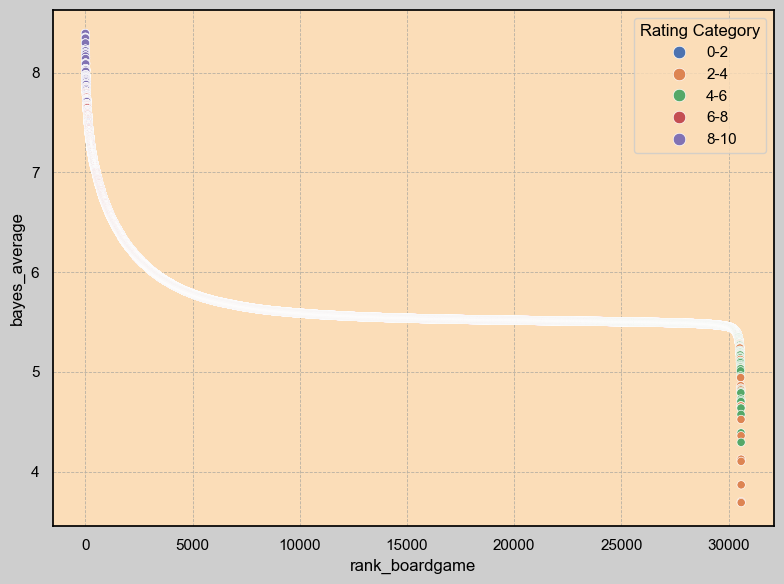

In [7]:
subplot_pairplot(df_plot, 0, 7,'rank_boardgame',  'bayes_average', 'rating_cat',legend='brief')

<Axes: >

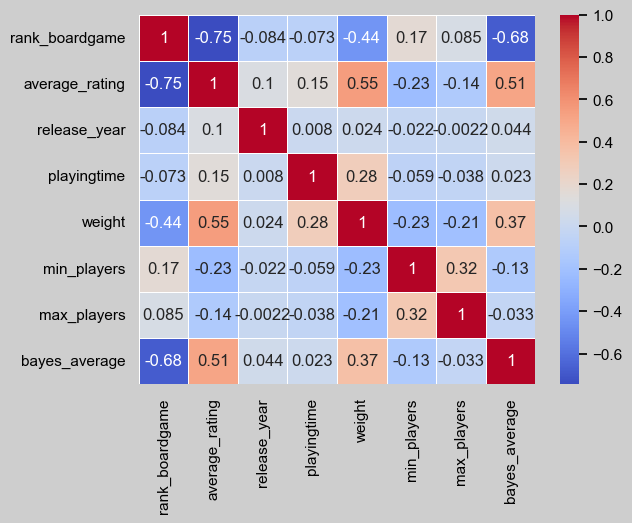

In [13]:
correlation_matrix = df_plot.select_dtypes(include=[np.number]).corr()
plt.Figure(figsize=(10, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, linecolor='white')

<Axes: xlabel='release_year'>

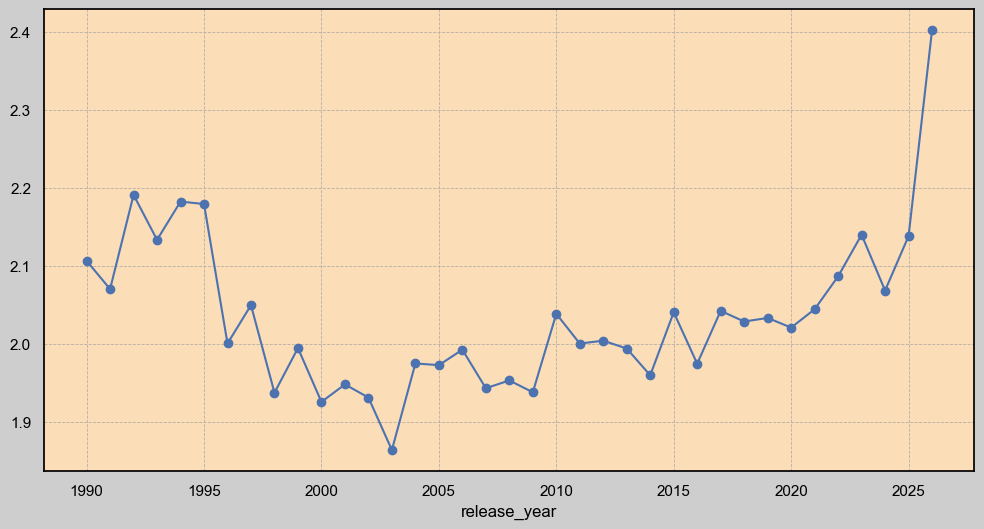

In [14]:
bgg_games_actual = bgg_games[bgg_games['release_year'] >= 1990]
# bgg_games_actual = bgg_games.copy()
bgg_games_actual.groupby('release_year')['weight'].mean().plot(kind='line', figsize=(12, 6), marker='o')


<Axes: xlabel='release_year'>

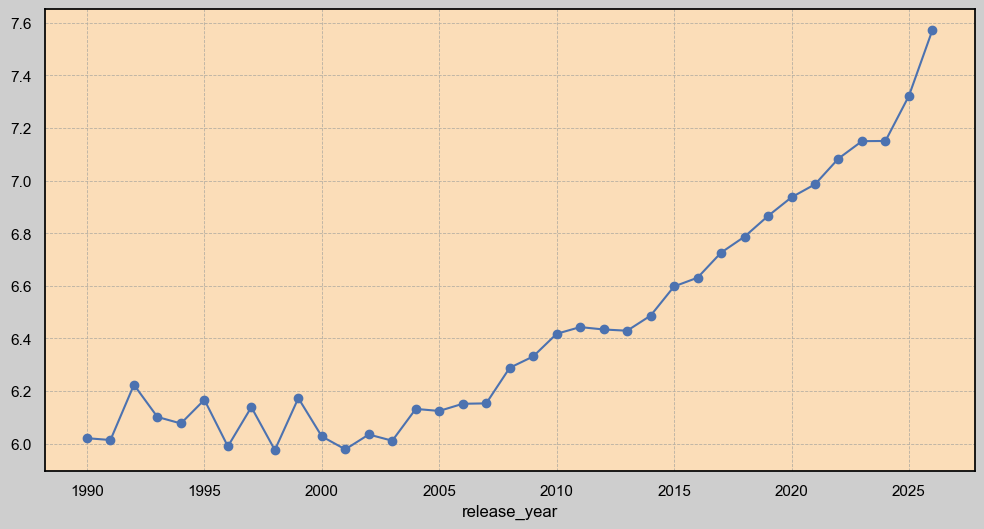

In [15]:
media_rating_por_anyo = bgg_games_actual.groupby('release_year')['average_rating'].mean()
media_rating_por_anyo.plot(kind='line', figsize=(12, 6), marker='o')

<BarContainer object of 37 artists>

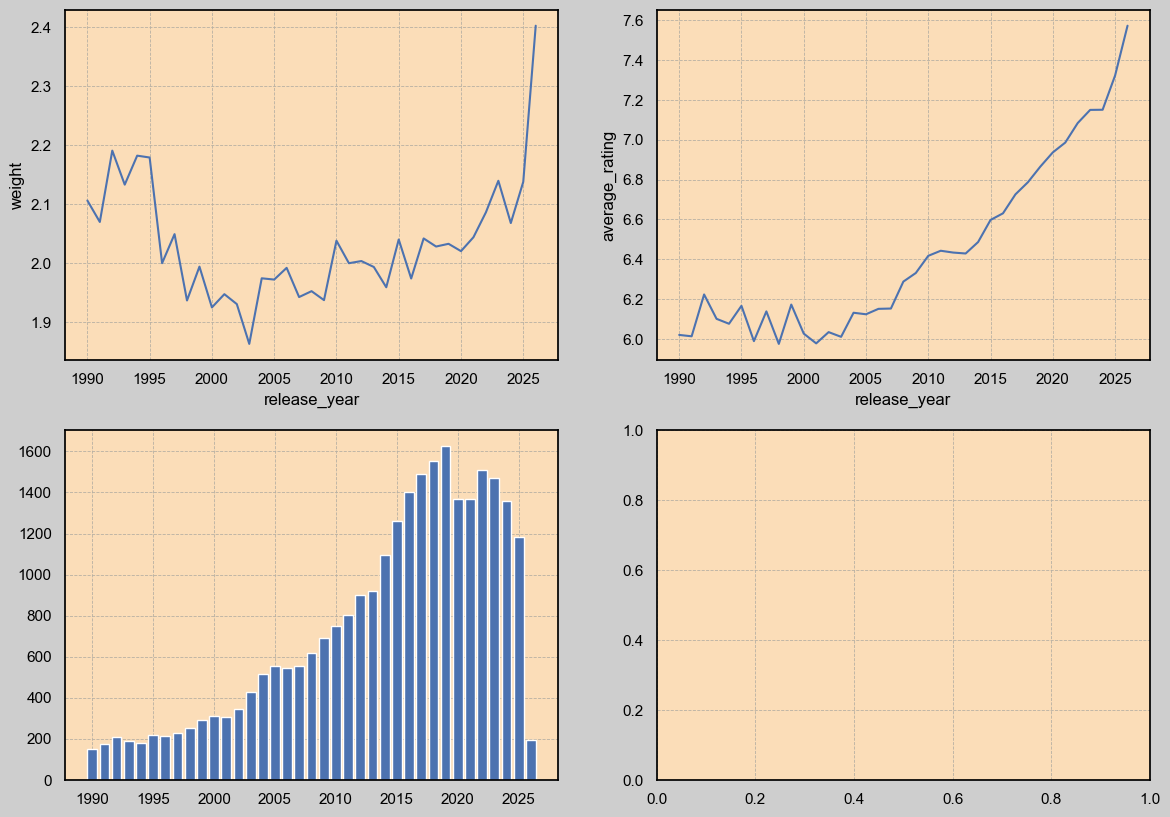

In [16]:
datos = bgg_games_actual.groupby('release_year').agg({
    'weight': 'mean',
    'average_rating': 'mean',
    'name': 'count'
    }).reset_index()
fig,ax = plt.subplots(2,2, figsize=(14, 10))
ax00 = ax[0,0]
sns.lineplot(data=datos, x='release_year', y='weight', ax=ax00)
ax01 = ax[0,1]
sns.lineplot(data=datos, x='release_year', y='average_rating', ax=ax01)
ax10 = ax[1,0]
ax10.bar(datos['release_year'], datos['name'])

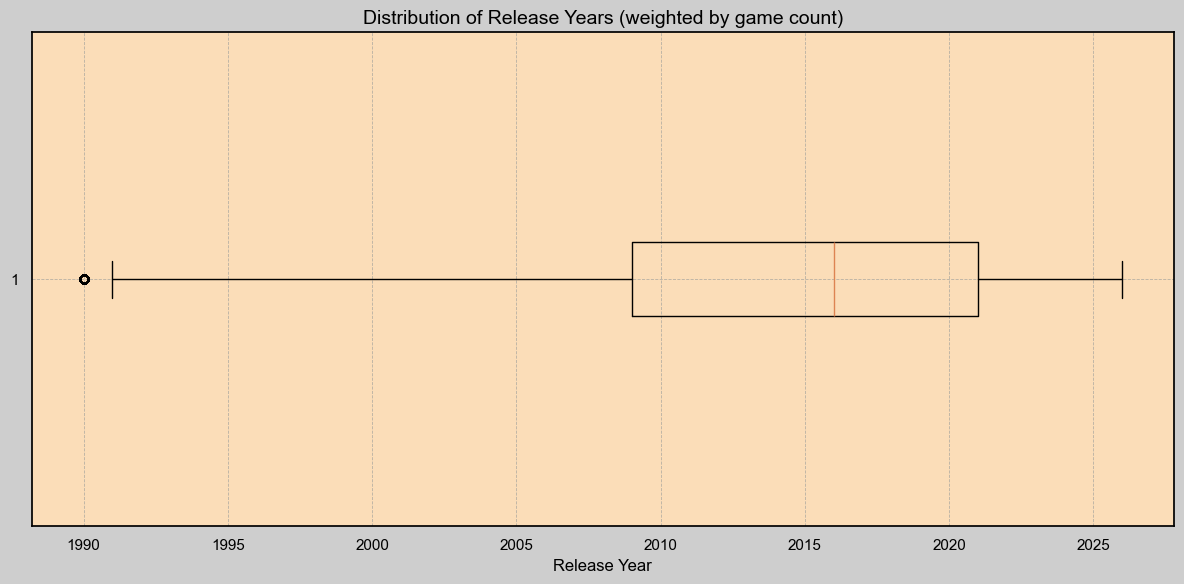

count    27234.000000
mean      2014.144158
std          8.443131
min       1990.000000
25%       2009.000000
50%       2016.000000
75%       2021.000000
max       2026.000000
dtype: float64

In [17]:
# Crear una lista con años repetidos según el conteo de juegos
years_expanded = []
for _, row in datos.iterrows():
    years_expanded.extend([row['release_year']] * int(row['name']))
years_expanded = pd.Series(years_expanded)
# Crear el boxplot
fig, ax_box = plt.subplots(figsize=(12, 6))
ax_box.boxplot(years_expanded, vert=False)
ax_box.set_xlabel('Release Year', fontsize=12)
ax_box.set_title('Distribution of Release Years (weighted by game count)', fontsize=14)
plt.tight_layout()
plt.show()

years_expanded.describe()

In [ ]:
sns.boxplot(data=bgg_games_actual, x='rating_cat', y='max_players', orient='h')
bgg_games_actual['max_players'].describe()

NameError: name 'sns' is not defined